In [1]:
import pandas as pd
import requests
from IPython.display import Image, display

## Initial dataset

Loading dataset

In [2]:
file_path = "exercises.csv"
df = pd.read_csv(file_path)

Analysing dataset

In [3]:
# Display basic info and show the first few rows
df.info(), df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1324 entries, 0 to 1323
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   bodyPart            1324 non-null   object
 1   equipment           1324 non-null   object
 2   gifUrl              1324 non-null   object
 3   id                  1324 non-null   int64 
 4   name                1324 non-null   object
 5   target              1324 non-null   object
 6   secondaryMuscles/0  1324 non-null   object
 7   secondaryMuscles/1  986 non-null    object
 8   instructions/0      1324 non-null   object
 9   instructions/1      1324 non-null   object
 10  instructions/2      1324 non-null   object
 11  instructions/3      1324 non-null   object
 12  instructions/4      1242 non-null   object
 13  instructions/5      739 non-null    object
 14  secondaryMuscles/2  233 non-null    object
 15  instructions/6      313 non-null    object
 16  instructions/7      92 n

(None,
      bodyPart    equipment                                         gifUrl  \
 0       waist  body weight  https://v2.exercisedb.io/image/MOnK4iG0MEt9h8   
 1       waist  body weight  https://v2.exercisedb.io/image/PERWLDGUxVbpHS   
 2       waist  body weight  https://v2.exercisedb.io/image/PLr4yo3j-f1amp   
 3  upper legs  body weight  https://v2.exercisedb.io/image/XPQwM7HECjgNFE   
 4       waist  body weight  https://v2.exercisedb.io/image/5nYph4eUGNiEdf   
 
      id                     name target secondaryMuscles/0 secondaryMuscles/1  \
 0     1               3/4 sit-up    abs        hip flexors         lower back   
 1     2            45° side bend    abs           obliques                NaN   
 2     3                 air bike    abs        hip flexors                NaN   
 3  1512  all fours squad stretch  quads         hamstrings             glutes   
 4     6  alternate heel touchers    abs           obliques                NaN   
 
                             

In [6]:
# Extract unique values from categorical columns
categorical_columns = ['bodyPart', 'equipment', 'target']

for col in categorical_columns:
    unique_vals = df[col].unique().tolist()
    print(f"{col} - {len(unique_vals)} unique values:\n{unique_vals}\n")

bodyPart - 10 unique values:
['waist', 'upper legs', 'back', 'lower legs', 'chest', 'upper arms', 'cardio', 'shoulders', 'lower arms', 'neck']

equipment - 28 unique values:
['body weight', 'cable', 'leverage machine', 'assisted', 'medicine ball', 'stability ball', 'band', 'barbell', 'rope', 'dumbbell', 'ez barbell', 'sled machine', 'upper body ergometer', 'kettlebell', 'olympic barbell', 'weighted', 'bosu ball', 'resistance band', 'roller', 'skierg machine', 'hammer', 'smith machine', 'wheel roller', 'stationary bike', 'tire', 'trap bar', 'elliptical machine', 'stepmill machine']

target - 19 unique values:
['abs', 'quads', 'lats', 'calves', 'pectorals', 'glutes', 'hamstrings', 'adductors', 'triceps', 'cardiovascular system', 'spine', 'upper back', 'biceps', 'delts', 'forearms', 'traps', 'serratus anterior', 'abductors', 'levator scapulae']



Checking GIF URLs

In [9]:
# Check the availability of gif URLs and display a few
working_gif_urls = []
broken_gif_urls = []

# Limit checks to the first 20 for display and quick results
for url in df['gifUrl'][:20]:
    try:
        response = requests.head(url, allow_redirects=True, timeout=5)
        if response.status_code == 200:
            working_gif_urls.append(url)
        else:
            broken_gif_urls.append(url)
    except requests.RequestException:
        broken_gif_urls.append(url)

# Display some working GIFs
for url in working_gif_urls[:5]:
    display(Image(url=url))

In [13]:
broken_gif_urls

['https://v2.exercisedb.io/image/MOnK4iG0MEt9h8',
 'https://v2.exercisedb.io/image/PERWLDGUxVbpHS',
 'https://v2.exercisedb.io/image/PLr4yo3j-f1amp',
 'https://v2.exercisedb.io/image/XPQwM7HECjgNFE',
 'https://v2.exercisedb.io/image/5nYph4eUGNiEdf',
 'https://v2.exercisedb.io/image/Az5UYVYNa4j-oS',
 'https://v2.exercisedb.io/image/ivmTcSJsMlXJeK',
 'https://v2.exercisedb.io/image/LSBkdKcbK4xj8n',
 'https://v2.exercisedb.io/image/GSjHZGSiL1VbQ7',
 'https://v2.exercisedb.io/image/osybi41Me6RFK2',
 'https://v2.exercisedb.io/image/yzS2EjySGDLmhh',
 'https://v2.exercisedb.io/image/sGs-MoFgyniLX4',
 'https://v2.exercisedb.io/image/WzINsIEOqFbBXG',
 'https://v2.exercisedb.io/image/AbxK1fjW5YdIBj',
 'https://v2.exercisedb.io/image/dgsJoe9nZI6G3Z',
 'https://v2.exercisedb.io/image/apDkfV7kzgRGlV',
 'https://v2.exercisedb.io/image/FHWElls92kFz7u',
 'https://v2.exercisedb.io/image/pIPCvG-7PYwJyb',
 'https://v2.exercisedb.io/image/re-rcIyamJTP9k',
 'https://v2.exercisedb.io/image/tcoPW9l8mI0o23']

All URLs are broken.

## Updated dataset (with watermarks)

Checking updated dataset

Loading dataset

In [14]:
file_path = "updated_fitness_exercises.csv"
df = pd.read_csv(file_path)

Analysing dataset

In [22]:
# Extract unique values from categorical columns
categorical_columns = ['bodyPart', 'equipment', 'target']

for col in categorical_columns:
    unique_vals = df[col].unique().tolist()
    print(f"{col} - {len(unique_vals)} unique values:\n{unique_vals}\n")

bodyPart - 10 unique values:
['waist', 'upper legs', 'back', 'lower legs', 'chest', 'upper arms', 'cardio', 'shoulders', 'lower arms', 'neck']

equipment - 28 unique values:
['body weight', 'cable', 'leverage machine', 'assisted', 'medicine ball', 'stability ball', 'band', 'barbell', 'rope', 'dumbbell', 'ez barbell', 'sled machine', 'upper body ergometer', 'kettlebell', 'olympic barbell', 'weighted', 'bosu ball', 'resistance band', 'roller', 'skierg machine', 'hammer', 'smith machine', 'wheel roller', 'stationary bike', 'tire', 'trap bar', 'elliptical machine', 'stepmill machine']

target - 19 unique values:
['abs', 'quads', 'lats', 'calves', 'pectorals', 'glutes', 'hamstrings', 'adductors', 'triceps', 'cardiovascular system', 'spine', 'upper back', 'biceps', 'delts', 'forearms', 'traps', 'serratus anterior', 'abductors', 'levator scapulae']



Checking GIF URLs

In [18]:
# Check the availability of gif URLs and display a few
working_gif_urls = []
broken_gif_urls = []

for idx, url in enumerate(df['gifUrl']):
    try:
        response = requests.head(url, allow_redirects=True, timeout=5)
        if response.status_code == 200:
            working_gif_urls.append(idx)
        else:
            broken_gif_urls.append(idx)
    except requests.RequestException:
        broken_gif_urls.append(idx)

In [19]:
len(working_gif_urls), len(broken_gif_urls)

(780, 547)

## Creating new dataset

Create new dataset with only working URLs

In [2]:
df_working = df.loc[working_gif_urls].reset_index(drop=True)

# Save to CSV
df_working.to_csv("exercises_working_gifs.csv", index=False)

NameError: name 'df' is not defined

Display some of them

In [21]:
# Display some working GIFs
for url in df_working['gifUrl'][:5]:
    display(Image(url=url))

Loading dataset

In [3]:
file_path = "exercises_working_gifs.csv"
df_working = pd.read_csv(file_path)

Analysis

In [23]:
# Extract unique values from categorical columns
categorical_columns = ['bodyPart', 'equipment', 'target']

for col in categorical_columns:
    unique_vals = df_working[col].unique().tolist()
    print(f"{col} - {len(unique_vals)} unique values:\n{unique_vals}\n")

bodyPart - 9 unique values:
['waist', 'upper legs', 'back', 'lower legs', 'chest', 'upper arms', 'cardio', 'shoulders', 'lower arms']

equipment - 14 unique values:
['body weight', 'cable', 'leverage machine', 'assisted', 'medicine ball', 'stability ball', 'band', 'barbell', 'rope', 'dumbbell', 'ez barbell', 'sled machine', 'upper body ergometer', 'kettlebell']

target - 17 unique values:
['abs', 'quads', 'lats', 'calves', 'glutes', 'pectorals', 'hamstrings', 'adductors', 'triceps', 'cardiovascular system', 'spine', 'upper back', 'biceps', 'delts', 'forearms', 'traps', 'serratus anterior']



Checking IDs

In [12]:
file_path = "exercises_working_gifs.csv"
df = pd.read_csv(file_path)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780 entries, 0 to 779
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   bodyPart   780 non-null    object
 1   equipment  780 non-null    object
 2   gifUrl     780 non-null    object
 3   id         780 non-null    int64 
 4   name       780 non-null    object
 5   target     780 non-null    object
dtypes: int64(1), object(5)
memory usage: 36.7+ KB


In [5]:
len(df['id'].unique())

780

Exercise distribution by part of body

In [16]:
# Count the number of rows for each unique body part
body_part_counts = df["bodyPart"].value_counts().reset_index()
body_part_counts.columns = ["bodyPart", "count"]

body_part_counts


,bodyPart,count
0,upper arms,227
1,upper legs,108
2,back,106
3,shoulders,95
4,chest,94
5,waist,83
6,lower legs,28
7,lower arms,27
8,cardio,12


Exercise distribution by equipment type

In [15]:
# Count the number of rows for each unique equipment
body_part_counts = df["equipment"].value_counts().reset_index()
body_part_counts.columns = ["equipment", "count"]

body_part_counts


,equipment,count
0,dumbbell,264
1,cable,137
2,body weight,136
3,barbell,119
4,band,41
5,stability ball,20
6,ez barbell,20
7,kettlebell,16
8,assisted,12
9,leverage machine,6


## Visualizations

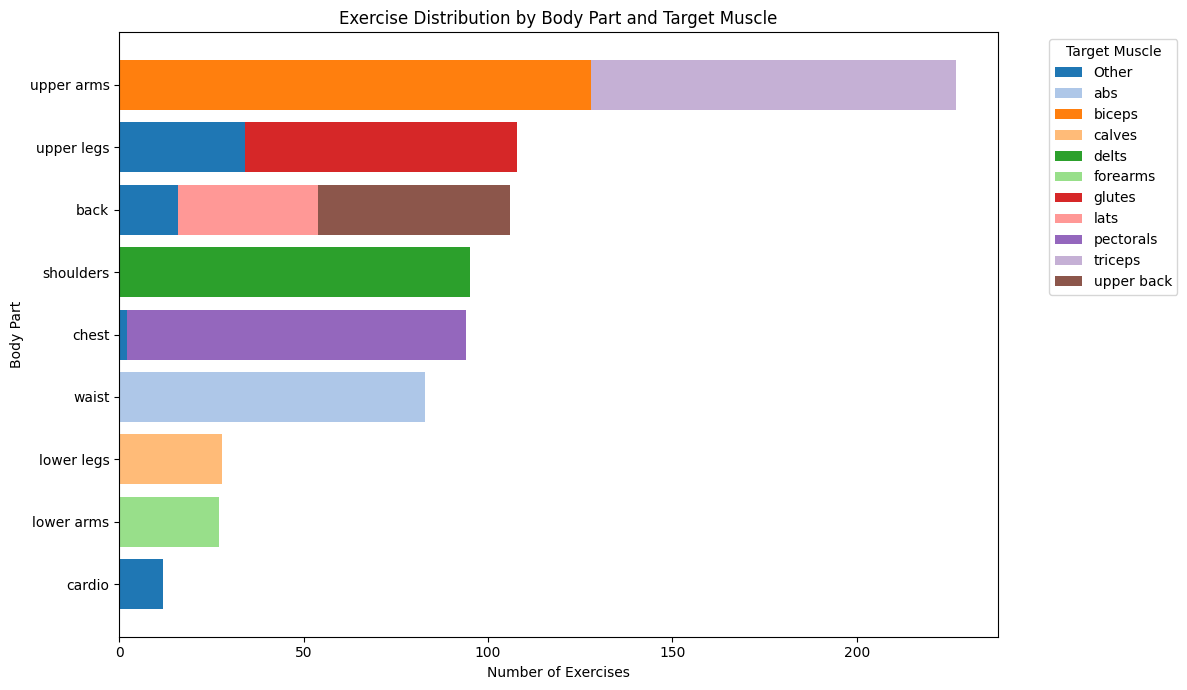

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('exercises_working_gifs.csv')

# Find top 10 target muscles overall
top_targets = df['target'].value_counts().head(10).index
df['target_grouped'] = df['target'].where(df['target'].isin(top_targets), other='Other')

# Count exercises by bodyPart and grouped target
pivot = df.pivot_table(
    index='bodyPart',
    columns='target_grouped',
    values='name',
    aggfunc='count',
    fill_value=0
)

pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=True).index]

# Color map for up to 11 groups (10 + Other)
cmap = plt.get_cmap('tab20')
colors = [cmap(i) for i in range(len(pivot.columns))]

fig, ax = plt.subplots(figsize=(12, 7))
bottom = np.zeros(len(pivot))

for i, col in enumerate(pivot.columns):
    values = pivot[col]
    ax.barh(pivot.index, values, left=bottom, label=col, color=colors[i])
    bottom += values

ax.set_xlabel('Number of Exercises')
ax.set_ylabel('Body Part')
ax.set_title('Exercise Distribution by Body Part and Target Muscle')
ax.legend(title='Target Muscle', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlim((0, bottom.max() * 1.05))  # Extend x-axis limit for better visibility
plt.tight_layout()
plt.show()
